In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns



# Load the dataset
df = pd.read_csv('Dataset/weed_detection1.csv')

# Split the data into features (X) and target variable (y)
X = df.drop(columns=['label'])
y = df['label']

# Perform preprocessing - standardization
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.08, random_state=2)


              precision    recall  f1-score   support

           0       0.67      0.23      0.35        77
           1       0.95      0.99      0.97      1117

    accuracy                           0.94      1194
   macro avg       0.81      0.61      0.66      1194
weighted avg       0.93      0.94      0.93      1194



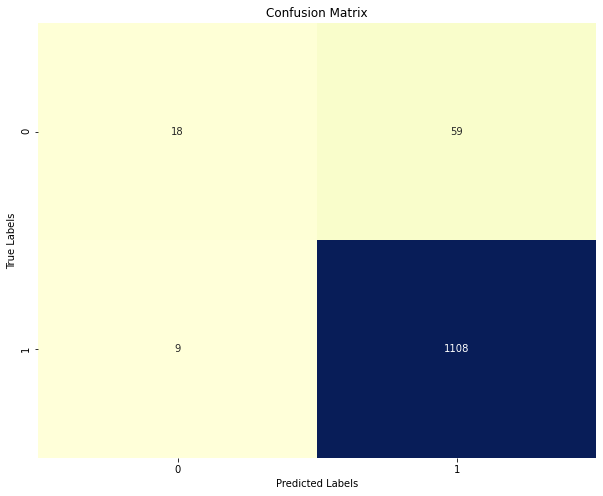

In [2]:
# Train and evaluate the Random Forest model
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)


print(classification_report(y_test, y_pred_rf))
cm = confusion_matrix(y_test, y_pred_rf)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap="YlGnBu", fmt="d", cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

In [3]:
# Train and evaluate the K-Nearest Neighbors model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("K-Nearest Neighbors Accuracy:", accuracy_knn)

K-Nearest Neighbors Accuracy: 0.940536013400335


In [4]:
# Train and evaluate the SVM model
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", accuracy_svm)

SVM Accuracy: 0.9422110552763819


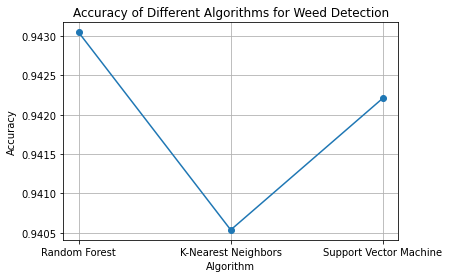

In [5]:
import matplotlib.pyplot as plt

# Create a line chart
algorithms = ['Random Forest', 'K-Nearest Neighbors', 'Support Vector Machine']
accuracies = [accuracy_rf, accuracy_knn, accuracy_svm]

plt.plot(algorithms, accuracies, marker='o')
plt.xlabel('Algorithm')
plt.ylabel('Accuracy')
plt.title('Accuracy of Different Algorithms for Weed Detection')
plt.grid(True)
plt.show()

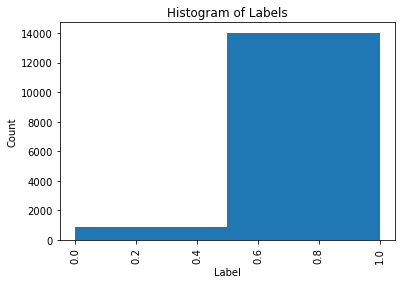

In [6]:
# Extract the label column
labels = df['label']

# Create a histogram
plt.hist(labels, bins=len(set(labels)))
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Histogram of Labels')
plt.xticks(rotation='vertical')
plt.show()